# Kapitel 3: Verteilungsparameter und mehrdimensionale Zufallsvariablen – Übungsbeispiele

**Statistik für Informatiker – DHBW Stuttgart**

In diesem Notebook werden die Konzepte aus Kapitel 3 anhand allgemeiner Beispiele veranschaulicht und geübt:
- Lageparameter (Erwartungswert, Median, Modus, Quantile)
- Streuungsparameter (Varianz, Standardabweichung, IQR)
- Kovarianz und Korrelation
- Gemeinsame Verteilungen und Randverteilungen
- Gesetz der großen Zahlen
- Zentraler Grenzwertsatz


## Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# Darstellung
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['mathtext.fontset'] = 'cm'
np.random.seed(42)

print("Setup abgeschlossen ✓")


Setup abgeschlossen ✓


---
## 1. Erwartungswert

Der **Erwartungswert** ist der Schwerpunkt einer Verteilung:

$$E(X) = \sum_i x_i \cdot P(X = x_i) \quad \text{(diskret)}$$

Er gibt den "langfristigen Durchschnitt" bei vielen Wiederholungen an.


### Beispiel 1: Fairer Würfel

Ein Würfel wird einmal geworfen. Die Zufallsvariable $X$ ist die Augenzahl.


In [2]:
# Erwartungswert eines fairen Würfels
x = np.arange(1, 7)
p = np.ones(6) / 6

E_X = np.sum(x * p)
E_X2 = np.sum(x**2 * p)

print("Fairer Würfel: X ∈ {1, 2, 3, 4, 5, 6}, P(X=k) = 1/6")
print(f"E(X) = Σ k·P(X=k) = {E_X:.4f}")
print(f"E(X²) = Σ k²·P(X=k) = {E_X2:.4f}")
print()
print("Hinweis: E(X) = 3.5 ist kein möglicher Wert des Würfels!")


Fairer Würfel: X ∈ {1, 2, 3, 4, 5, 6}, P(X=k) = 1/6
E(X) = Σ k·P(X=k) = 3.5000
E(X²) = Σ k²·P(X=k) = 15.1667

Hinweis: E(X) = 3.5 ist kein möglicher Wert des Würfels!


### Beispiel 2: Gewichtete Münze

Eine Münze zeigt mit Wahrscheinlichkeit $p = 0{,}7$ Kopf ($X = 1$) und mit $1-p = 0{,}3$ Zahl ($X = 0$).


In [3]:
p_kopf = 0.7
E_muenze = 1 * p_kopf + 0 * (1 - p_kopf)
print(f"Gewichtete Münze: P(Kopf) = {p_kopf}")
print(f"E(X) = 1·{p_kopf} + 0·{1-p_kopf} = {E_muenze}")
print(f"→ Der Erwartungswert entspricht hier direkt der Erfolgswahrscheinlichkeit")


Gewichtete Münze: P(Kopf) = 0.7
E(X) = 1·0.7 + 0·0.30000000000000004 = 0.7
→ Der Erwartungswert entspricht hier direkt der Erfolgswahrscheinlichkeit


### Rechenregeln für den Erwartungswert

Für Konstanten $a, b$ und Zufallsvariablen $X, Y$:
- $E(aX + b) = a \cdot E(X) + b$
- $E(X + Y) = E(X) + E(Y)$ (immer, auch bei Abhängigkeit!)


In [4]:
# Rechenregeln demonstrieren
E_X = 3.5  # Würfel

# Y = 2X + 3
E_Y = 2 * E_X + 3
print(f"X = Würfelwurf → E(X) = {E_X}")
print(f"Y = 2X + 3    → E(Y) = 2·{E_X} + 3 = {E_Y}")
print()

# Summe zweier Würfel
print(f"Zwei unabhängige Würfel: E(X₁ + X₂) = E(X₁) + E(X₂) = {E_X} + {E_X} = {2*E_X}")
print(f"→ Die Linearität gilt IMMER, auch bei abhängigen Variablen!")


X = Würfelwurf → E(X) = 3.5
Y = 2X + 3    → E(Y) = 2·3.5 + 3 = 10.0

Zwei unabhängige Würfel: E(X₁ + X₂) = E(X₁) + E(X₂) = 3.5 + 3.5 = 7.0
→ Die Linearität gilt IMMER, auch bei abhängigen Variablen!


---
## 2. Median und Modus

- **Median**: Teilt die Verteilung in zwei gleich große Hälften (robust gegen Ausreißer)
- **Modus**: Häufigster Wert (diskret) bzw. Maximum der Dichte (stetig)


### Beispiel: Gehälter in einem Unternehmen

Typisches Beispiel für den Unterschied zwischen Mittelwert und Median.


In [5]:
# 9 Angestellte + 1 Geschäftsführer
gehaelter = np.array([2800, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3800, 12000])

mittelwert = np.mean(gehaelter)
median = np.median(gehaelter)

print("Monatsgehälter (€):", gehaelter)
print(f"\nMittelwert: {mittelwert:.0f} €")
print(f"Median:     {median:.0f} €")
print(f"\n→ Der Mittelwert wird durch das Ausreißer-Gehalt (12.000 €) stark verzerrt.")
print(f"→ Der Median ({median:.0f} €) beschreibt das 'typische' Gehalt besser.")

# Ohne Ausreißer
mittelwert_ohne = np.mean(gehaelter[:-1])
median_ohne = np.median(gehaelter[:-1])
print(f"\nOhne Ausreißer: Mittelwert = {mittelwert_ohne:.0f} €, Median = {median_ohne:.0f} €")
print(f"Änderung: Mittelwert ändert sich um {mittelwert - mittelwert_ohne:.0f} €, "
      f"Median nur um {median - median_ohne:.0f} €")


Monatsgehälter (€): [ 2800  3000  3100  3200  3300  3400  3500  3600  3800 12000]

Mittelwert: 4170 €
Median:     3350 €

→ Der Mittelwert wird durch das Ausreißer-Gehalt (12.000 €) stark verzerrt.
→ Der Median (3350 €) beschreibt das 'typische' Gehalt besser.

Ohne Ausreißer: Mittelwert = 3300 €, Median = 3300 €
Änderung: Mittelwert ändert sich um 870 €, Median nur um 50 €


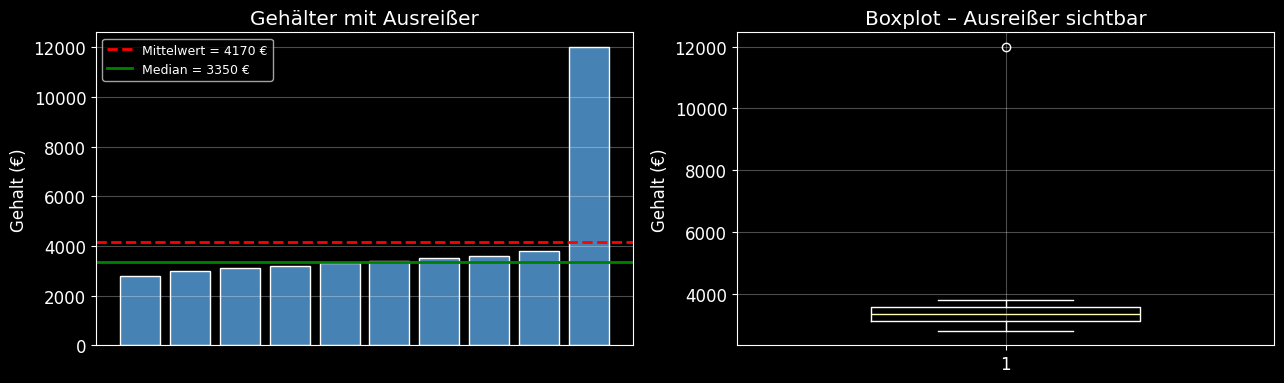

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Links: Mit Ausreißer
ax = axes[0]
ax.bar(range(len(gehaelter)), sorted(gehaelter), color='steelblue', edgecolor='white')
ax.axhline(mittelwert, color='red', linestyle='--', linewidth=2, label=f'Mittelwert = {mittelwert:.0f} €')
ax.axhline(median, color='green', linestyle='-', linewidth=2, label=f'Median = {median:.0f} €')
ax.set_ylabel('Gehalt (€)')
ax.set_title('Gehälter mit Ausreißer')
ax.legend(fontsize=9)
ax.set_xticks([])

# Rechts: Boxplot
ax = axes[1]
ax.boxplot(gehaelter, vert=True, widths=0.5)
ax.set_ylabel('Gehalt (€)')
ax.set_title('Boxplot – Ausreißer sichtbar')

plt.tight_layout()
plt.show()


---
## 3. Quantile und Interquartilsabstand (IQR)

Das **$p$-Quantil** $x_p$ ist der Wert, unterhalb dessen ein Anteil $p$ der Verteilung liegt.

Der **IQR** umfasst die mittleren 50 %:
$$\mathrm{IQR} = Q_3 - Q_1 = x_{0{,}75} - x_{0{,}25}$$


### Beispiel: Prüfungsergebnisse

50 Studierende schreiben eine Klausur (max. 100 Punkte).


In [7]:
np.random.seed(123)
punkte = np.random.normal(65, 12, 50).astype(int)
punkte = np.clip(punkte, 0, 100)
punkte.sort()

Q1 = np.percentile(punkte, 25)
Q2 = np.percentile(punkte, 50)  # Median
Q3 = np.percentile(punkte, 75)
IQR = Q3 - Q1

print(f"Prüfungsergebnisse (n = {len(punkte)}):")
print(f"Min = {punkte.min()}, Max = {punkte.max()}")
print(f"\nQ₁ (25%-Quantil) = {Q1:.1f} Punkte")
print(f"Q₂ (Median)       = {Q2:.1f} Punkte")
print(f"Q₃ (75%-Quantil) = {Q3:.1f} Punkte")
print(f"IQR = Q₃ - Q₁ = {Q3:.1f} - {Q1:.1f} = {IQR:.1f} Punkte")
print(f"\nDie mittleren 50 % der Studierenden liegen zwischen {Q1:.0f} und {Q3:.0f} Punkten.")

# Ausreißergrenzen
untere = Q1 - 1.5 * IQR
obere = Q3 + 1.5 * IQR
ausreisser = punkte[(punkte < untere) | (punkte > obere)]
print(f"\nAusreißergrenzen (1,5·IQR-Regel):")
print(f"  Untere Grenze: {Q1:.1f} - 1,5·{IQR:.1f} = {untere:.1f}")
print(f"  Obere Grenze:  {Q3:.1f} + 1,5·{IQR:.1f} = {obere:.1f}")
print(f"  Ausreißer: {ausreisser if len(ausreisser) > 0 else 'keine'}")


Prüfungsergebnisse (n = 50):
Min = 31, Max = 93

Q₁ (25%-Quantil) = 55.2 Punkte
Q₂ (Median)       = 63.0 Punkte
Q₃ (75%-Quantil) = 75.8 Punkte
IQR = Q₃ - Q₁ = 75.8 - 55.2 = 20.5 Punkte

Die mittleren 50 % der Studierenden liegen zwischen 55 und 76 Punkten.

Ausreißergrenzen (1,5·IQR-Regel):
  Untere Grenze: 55.2 - 1,5·20.5 = 24.5
  Obere Grenze:  75.8 + 1,5·20.5 = 106.5
  Ausreißer: keine


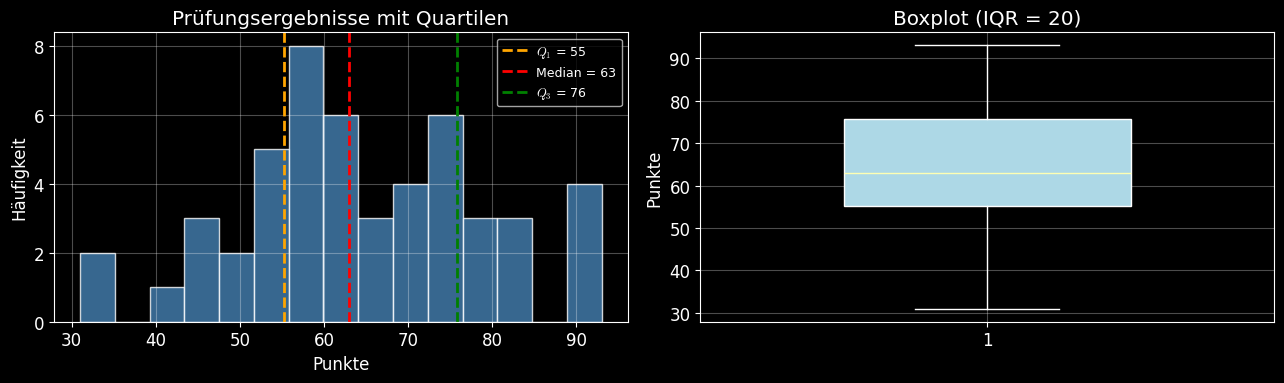

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogramm mit Quartilen
ax = axes[0]
ax.hist(punkte, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
for q, label, col in [(Q1, '$Q_1$', 'orange'), (Q2, 'Median', 'red'), (Q3, '$Q_3$', 'green')]:
    ax.axvline(q, color=col, linestyle='--', linewidth=2, label=f'{label} = {q:.0f}')
ax.set_xlabel('Punkte')
ax.set_ylabel('Häufigkeit')
ax.set_title('Prüfungsergebnisse mit Quartilen')
ax.legend(fontsize=9)

# Boxplot
ax = axes[1]
bp = ax.boxplot(punkte, vert=True, widths=0.5, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax.set_ylabel('Punkte')
ax.set_title(f'Boxplot (IQR = {IQR:.0f})')

plt.tight_layout()
plt.show()


---
## 4. Varianz und Standardabweichung

Die **Varianz** misst die mittlere quadratische Abweichung vom Erwartungswert:

$$\mathrm{Var}(X) = E[(X - E(X))^2] = E(X^2) - [E(X)]^2 \quad \text{(Verschiebungsformel)}$$

Die **Standardabweichung** $\sigma(X) = \sqrt{\mathrm{Var}(X)}$ hat dieselbe Einheit wie $X$.


### Beispiel 1: Würfelwurf – Varianz berechnen


In [9]:
x = np.arange(1, 7)
p = np.ones(6) / 6

E_X = np.sum(x * p)
E_X2 = np.sum(x**2 * p)
Var_X = E_X2 - E_X**2
sigma_X = np.sqrt(Var_X)

print("Fairer Würfel:")
print(f"E(X)   = {E_X}")
print(f"E(X²)  = {E_X2:.4f}")
print(f"\nVersionchiebungsformel:")
print(f"Var(X) = E(X²) - [E(X)]² = {E_X2:.4f} - {E_X}² = {E_X2:.4f} - {E_X**2:.4f} = {Var_X:.4f}")
print(f"         = 35/12 ≈ {35/12:.4f} ✓")
print(f"\nσ(X)   = √Var(X) = √{Var_X:.4f} = {sigma_X:.4f}")


Fairer Würfel:
E(X)   = 3.5
E(X²)  = 15.1667

Versionchiebungsformel:
Var(X) = E(X²) - [E(X)]² = 15.1667 - 3.5² = 15.1667 - 12.2500 = 2.9167
         = 35/12 ≈ 2.9167 ✓

σ(X)   = √Var(X) = √2.9167 = 1.7078


### Beispiel 2: Rechenregeln – Var(aX+b)


In [10]:
# Var(aX + b) = a² · Var(X)
Var_X = 35/12
a, b = 3, 10

Var_Y = a**2 * Var_X
sigma_Y = np.sqrt(Var_Y)

print(f"X = Würfelwurf: Var(X) = {Var_X:.4f}")
print(f"Y = {a}X + {b}")
print(f"\nVar(Y) = {a}² · Var(X) = {a**2} · {Var_X:.4f} = {Var_Y:.4f}")
print(f"σ(Y) = {sigma_Y:.4f}")
print(f"\n→ Die Konstante b = {b} verändert die Varianz NICHT!")
print(f"→ Der Faktor a = {a} geht QUADRATISCH ein.")


X = Würfelwurf: Var(X) = 2.9167
Y = 3X + 10

Var(Y) = 3² · Var(X) = 9 · 2.9167 = 26.2500
σ(Y) = 5.1235

→ Die Konstante b = 10 verändert die Varianz NICHT!
→ Der Faktor a = 3 geht QUADRATISCH ein.


### Beispiel 3: Varianz der Summe unabhängiger Variablen

Zwei unabhängige Würfel: $\mathrm{Var}(X_1 + X_2) = \mathrm{Var}(X_1) + \mathrm{Var}(X_2)$


In [11]:
Var_wuerfel = 35/12

Var_summe = 2 * Var_wuerfel
sigma_summe = np.sqrt(Var_summe)

print(f"Var(X₁) = Var(X₂) = {Var_wuerfel:.4f}")
print(f"Var(X₁ + X₂) = {Var_wuerfel:.4f} + {Var_wuerfel:.4f} = {Var_summe:.4f}")
print(f"σ(X₁ + X₂) = {sigma_summe:.4f}")
print()
print(f"Beachte: σ(X₁ + X₂) = {sigma_summe:.4f} ≠ 2·σ(X₁) = {2*np.sqrt(Var_wuerfel):.4f}")
print(f"→ Standardabweichungen addieren sich NICHT direkt!")

# Simulation zur Überprüfung
np.random.seed(42)
w1 = np.random.randint(1, 7, 100_000)
w2 = np.random.randint(1, 7, 100_000)
print(f"\nSimulation (n=100.000):")
print(f"  Var(X₁ + X₂) ≈ {np.var(w1 + w2):.4f}  (Theorie: {Var_summe:.4f})")


Var(X₁) = Var(X₂) = 2.9167
Var(X₁ + X₂) = 2.9167 + 2.9167 = 5.8333
σ(X₁ + X₂) = 2.4152

Beachte: σ(X₁ + X₂) = 2.4152 ≠ 2·σ(X₁) = 3.4157
→ Standardabweichungen addieren sich NICHT direkt!

Simulation (n=100.000):
  Var(X₁ + X₂) ≈ 5.8198  (Theorie: 5.8333)


---
## 5. Erwartungswert und Varianz wichtiger Verteilungen

| Verteilung | $E(X)$ | $\mathrm{Var}(X)$ |
|---|---|---|
| $B(n, p)$ | $np$ | $np(1-p)$ |
| $\mathrm{Po}(\lambda)$ | $\lambda$ | $\lambda$ |
| $U[a, b]$ | $\frac{a+b}{2}$ | $\frac{(b-a)^2}{12}$ |
| $\mathrm{Exp}(\lambda)$ | $\frac{1}{\lambda}$ | $\frac{1}{\lambda^2}$ |
| $N(\mu, \sigma^2)$ | $\mu$ | $\sigma^2$ |


### Überprüfung per Simulation


In [12]:
np.random.seed(42)
n_sim = 500_000

verteilungen = [
    ("B(50, 0.4)",   stats.binom(50, 0.4),     50*0.4,      50*0.4*0.6),
    ("Po(7)",        stats.poisson(7),           7,           7),
    ("U[2, 10]",     stats.uniform(2, 8),        6,           64/12),
    ("Exp(0.5)",     stats.expon(scale=2),        2,           4),
    ("N(100, 25)",   stats.norm(100, 5),          100,         25),
]

print(f"{'Verteilung':<14} {'E(X) Theorie':>13} {'E(X) Sim.':>10} {'Var(X) Th.':>11} {'Var(X) Sim.':>12}")
print("-" * 64)
for name, dist, e_th, v_th in verteilungen:
    samples = dist.rvs(n_sim)
    print(f"{name:<14} {e_th:>13.4f} {np.mean(samples):>10.4f} {v_th:>11.4f} {np.var(samples):>12.4f}")

print(f"\n→ Bei n = {n_sim:,} Simulationen stimmen Theorie und Simulation sehr gut überein.")


Verteilung      E(X) Theorie  E(X) Sim.  Var(X) Th.  Var(X) Sim.
----------------------------------------------------------------
B(50, 0.4)           20.0000    20.0028     12.0000      11.9793
Po(7)                 7.0000     6.9968      7.0000       7.0007
U[2, 10]              6.0000     6.0010      5.3333       5.3363
Exp(0.5)              2.0000     1.9973      4.0000       3.9977
N(100, 25)          100.0000   100.0022     25.0000      25.0056

→ Bei n = 500,000 Simulationen stimmen Theorie und Simulation sehr gut überein.


---
## 6. Kovarianz und Korrelation

Die **Kovarianz** misst den linearen Zusammenhang zweier Variablen:
$$\mathrm{Cov}(X, Y) = E(XY) - E(X) \cdot E(Y)$$

Die **Korrelation** ist die normierte Kovarianz:
$$\rho(X,Y) = \frac{\mathrm{Cov}(X,Y)}{\sigma_X \cdot \sigma_Y} \in [-1, 1]$$


### Beispiel: Temperatur und Eisverkauf

Über 12 Monate werden die mittlere Temperatur und der Eisverkauf erfasst.


In [13]:
# Monatsdaten
monate = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun',
          'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']
temperatur = np.array([1, 3, 8, 13, 18, 22, 25, 24, 19, 12, 6, 2])
eis_verkauf = np.array([20, 25, 40, 80, 150, 250, 310, 290, 180, 70, 30, 22])

# Mittelwerte
x_bar = np.mean(temperatur)
y_bar = np.mean(eis_verkauf)

# Kovarianz (manuell)
cov_xy = np.mean((temperatur - x_bar) * (eis_verkauf - y_bar))
sigma_x = np.std(temperatur)
sigma_y = np.std(eis_verkauf)
rho = cov_xy / (sigma_x * sigma_y)

print("Temperatur und Eisverkauf (12 Monate)")
print(f"{'Monat':<6} {'Temp (°C)':>10} {'Eis (Stk.)':>12}")
print("-" * 30)
for m, t, e in zip(monate, temperatur, eis_verkauf):
    print(f"{m:<6} {t:>10} {e:>12}")

print(f"\nMittelwerte: x̄ = {x_bar:.1f} °C,  ȳ = {y_bar:.1f} Stk.")
print(f"Cov(X,Y) = {cov_xy:.2f}")
print(f"σ_X = {sigma_x:.2f},  σ_Y = {sigma_y:.2f}")
print(f"ρ(X,Y) = {rho:.4f}")
print(f"\n→ Starke positive Korrelation: Höhere Temperatur geht mit mehr Eisverkauf einher.")


Temperatur und Eisverkauf (12 Monate)
Monat   Temp (°C)   Eis (Stk.)
------------------------------
Jan             1           20
Feb             3           25
Mär             8           40
Apr            13           80
Mai            18          150
Jun            22          250
Jul            25          310
Aug            24          290
Sep            19          180
Okt            12           70
Nov             6           30
Dez             2           22

Mittelwerte: x̄ = 12.8 °C,  ȳ = 122.2 Stk.
Cov(X,Y) = 845.40
σ_X = 8.40,  σ_Y = 105.50
ρ(X,Y) = 0.9542

→ Starke positive Korrelation: Höhere Temperatur geht mit mehr Eisverkauf einher.


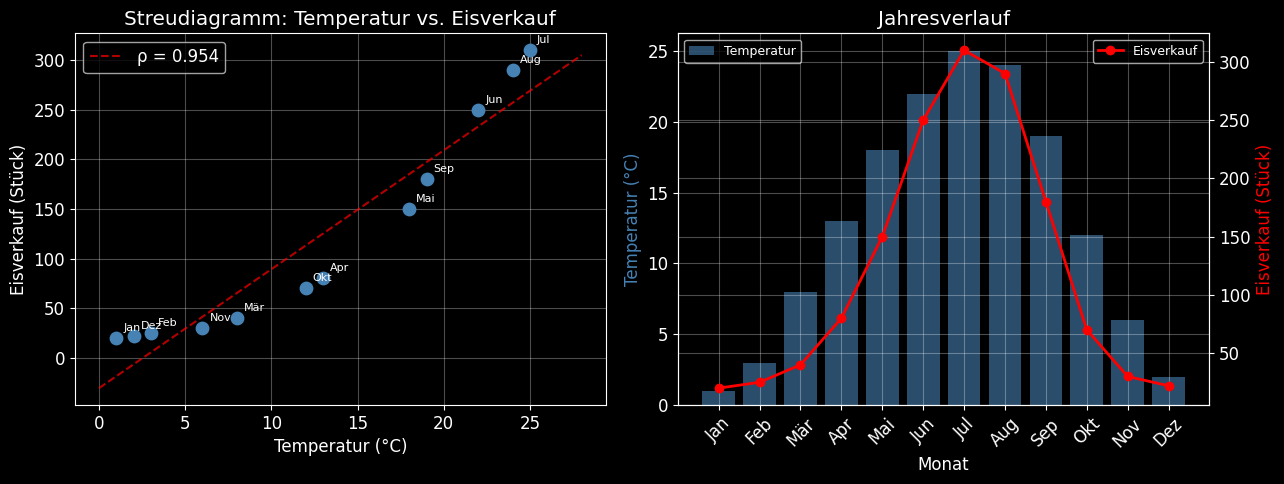

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Streudiagramm
ax = axes[0]
ax.scatter(temperatur, eis_verkauf, color='steelblue', s=80, zorder=3)
for m, t, e in zip(monate, temperatur, eis_verkauf):
    ax.annotate(m, (t, e), textcoords="offset points", xytext=(5, 5), fontsize=8)
# Regressionslinie
z = np.polyfit(temperatur, eis_verkauf, 1)
x_line = np.linspace(0, 28, 100)
ax.plot(x_line, np.polyval(z, x_line), 'r--', alpha=0.7, label=f'ρ = {rho:.3f}')
ax.set_xlabel('Temperatur (°C)')
ax.set_ylabel('Eisverkauf (Stück)')
ax.set_title('Streudiagramm: Temperatur vs. Eisverkauf')
ax.legend()

# Zeitreihe
ax = axes[1]
ax2 = ax.twinx()
ax.bar(range(12), temperatur, color='steelblue', alpha=0.6, label='Temperatur')
ax2.plot(range(12), eis_verkauf, 'ro-', linewidth=2, label='Eisverkauf')
ax.set_xlabel('Monat')
ax.set_ylabel('Temperatur (°C)', color='steelblue')
ax2.set_ylabel('Eisverkauf (Stück)', color='red')
ax.set_xticks(range(12))
ax.set_xticklabels(monate, rotation=45)
ax.set_title('Jahresverlauf')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


### Korrelation ≠ Kausalität

Ein hoher Korrelationskoeffizient zeigt nur einen statistischen Zusammenhang – keine Ursache-Wirkungs-Beziehung!


In [15]:
# Klassisches Beispiel: Scheinkorrelation
np.random.seed(42)
monate_idx = np.arange(1, 13)

# Eisverkauf und Ertrinkungsfälle korrelieren beide mit Temperatur
eis = 50 + 10 * temperatur + np.random.normal(0, 15, 12)
ertrinken = 2 + 0.3 * temperatur + np.random.normal(0, 1, 12)

rho_schein = np.corrcoef(eis, ertrinken)[0, 1]
print(f"Korrelation zwischen Eisverkauf und Ertrinkungsfällen: ρ = {rho_schein:.3f}")
print(f"→ Hohe positive Korrelation!")
print(f"→ Aber: Eis essen verursacht KEIN Ertrinken!")
print(f"→ Gemeinsame Ursache: hohe Temperatur im Sommer")
print(f"\n⚠ Korrelation ≠ Kausalität!")


Korrelation zwischen Eisverkauf und Ertrinkungsfällen: ρ = 0.926
→ Hohe positive Korrelation!
→ Aber: Eis essen verursacht KEIN Ertrinken!
→ Gemeinsame Ursache: hohe Temperatur im Sommer

⚠ Korrelation ≠ Kausalität!


### Übung: Lernzeit und Klausurnote

Berechne Kovarianz und Korrelation manuell.


In [16]:
lernzeit = np.array([2, 5, 8, 12, 15])   # Stunden
note = np.array([4.0, 3.3, 2.7, 1.7, 1.0])  # Schulnote

x_bar = np.mean(lernzeit)
y_bar = np.mean(note)
cov = np.mean((lernzeit - x_bar) * (note - y_bar))
sx = np.std(lernzeit)
sy = np.std(note)
rho = cov / (sx * sy)

print("Lernzeit (h) vs. Klausurnote:")
print(f"x̄ = {x_bar:.1f} h,  ȳ = {y_bar:.2f}")
print(f"\nAbweichungstabelle:")
print(f"{'x_i':>5} {'y_i':>6} {'x-x̄':>7} {'y-ȳ':>7} {'(x-x̄)(y-ȳ)':>12}")
print("-" * 40)
for xi, yi in zip(lernzeit, note):
    dx = xi - x_bar
    dy = yi - y_bar
    print(f"{xi:>5} {yi:>6.1f} {dx:>7.1f} {dy:>7.2f} {dx*dy:>12.2f}")

print(f"\nCov(X,Y) = {cov:.4f}")
print(f"ρ(X,Y) = {rho:.4f}")
print(f"\n→ Starke negative Korrelation: Mehr Lernzeit geht mit besserer (niedrigerer) Note einher.")


Lernzeit (h) vs. Klausurnote:
x̄ = 8.4 h,  ȳ = 2.54

Abweichungstabelle:
  x_i    y_i    x-x̄     y-ȳ  (x-x̄)(y-ȳ)
----------------------------------------
    2    4.0    -6.4    1.46        -9.34
    5    3.3    -3.4    0.76        -2.58
    8    2.7    -0.4    0.16        -0.06
   12    1.7     3.6   -0.84        -3.02
   15    1.0     6.6   -1.54       -10.16

Cov(X,Y) = -5.0360
ρ(X,Y) = -0.9995

→ Starke negative Korrelation: Mehr Lernzeit geht mit besserer (niedrigerer) Note einher.


---
## 7. Gemeinsame Verteilungen und Randverteilungen

Die **gemeinsame Verteilung** $P(X=x, Y=y)$ beschreibt, wie zwei Zufallsvariablen zusammen verteilt sind.

Die **Randverteilungen** ergeben sich durch Summation über die jeweils andere Variable.


### Beispiel: Medizinischer Test

Ein medizinischer Test wird an einer Population durchgeführt.
- $X$: Testergebnis (0 = negativ, 1 = positiv)
- $Y$: Wahrer Zustand (0 = gesund, 1 = krank)


In [17]:
# Gemeinsame Verteilung als Tabelle
joint = np.array([[0.80, 0.03],   # X=0 (negativ)
                  [0.05, 0.12]])   # X=1 (positiv)

# Randverteilungen
p_X = joint.sum(axis=1)  # Summe über Y
p_Y = joint.sum(axis=0)  # Summe über X

print("Gemeinsame Verteilung P(X, Y):")
print(f"{'':>10} {'Y=0 (gesund)':>14} {'Y=1 (krank)':>14} {'P(X=x)':>10}")
print("-" * 52)
labels_x = ['X=0 (neg.)', 'X=1 (pos.)']
for i, label in enumerate(labels_x):
    print(f"{label:>10} {joint[i,0]:>14.2f} {joint[i,1]:>14.2f} {p_X[i]:>10.2f}")
print("-" * 52)
print(f"{'P(Y=y)':>10} {p_Y[0]:>14.2f} {p_Y[1]:>14.2f} {joint.sum():>10.2f}")

print(f"\nRandverteilung X: P(X=0) = {p_X[0]:.2f}, P(X=1) = {p_X[1]:.2f}")
print(f"Randverteilung Y: P(Y=0) = {p_Y[0]:.2f}, P(Y=1) = {p_Y[1]:.2f}")


Gemeinsame Verteilung P(X, Y):
             Y=0 (gesund)    Y=1 (krank)     P(X=x)
----------------------------------------------------
X=0 (neg.)           0.80           0.03       0.83
X=1 (pos.)           0.05           0.12       0.17
----------------------------------------------------
    P(Y=y)           0.85           0.15       1.00

Randverteilung X: P(X=0) = 0.83, P(X=1) = 0.17
Randverteilung Y: P(Y=0) = 0.85, P(Y=1) = 0.15


In [18]:
# Bedingte Wahrscheinlichkeiten
sensitivitaet = joint[1, 1] / p_Y[1]      # P(X=1 | Y=1)
spezifitaet = joint[0, 0] / p_Y[0]        # P(X=0 | Y=0)
ppv = joint[1, 1] / p_X[1]                # P(Y=1 | X=1)
npv = joint[0, 0] / p_X[0]                # P(Y=0 | X=0)

print("Bedingte Wahrscheinlichkeiten:")
print(f"  Sensitivität  P(X=1|Y=1) = {joint[1,1]:.2f}/{p_Y[1]:.2f} = {sensitivitaet:.3f}")
print(f"  Spezifität    P(X=0|Y=0) = {joint[0,0]:.2f}/{p_Y[0]:.2f} = {spezifitaet:.3f}")
print(f"  Pos. Vorhersagewert P(Y=1|X=1) = {joint[1,1]:.2f}/{p_X[1]:.2f} = {ppv:.3f}")
print(f"  Neg. Vorhersagewert P(Y=0|X=0) = {joint[0,0]:.2f}/{p_X[0]:.2f} = {npv:.3f}")

# Unabhängigkeitsprüfung
print(f"\nUnabhängigkeitsprüfung:")
print(f"  P(X=0,Y=0) = {joint[0,0]:.2f}")
print(f"  P(X=0)·P(Y=0) = {p_X[0]:.2f}·{p_Y[0]:.2f} = {p_X[0]*p_Y[0]:.4f}")
print(f"  → {joint[0,0]:.2f} ≠ {p_X[0]*p_Y[0]:.4f} → X und Y sind NICHT unabhängig ✓")


Bedingte Wahrscheinlichkeiten:
  Sensitivität  P(X=1|Y=1) = 0.12/0.15 = 0.800
  Spezifität    P(X=0|Y=0) = 0.80/0.85 = 0.941
  Pos. Vorhersagewert P(Y=1|X=1) = 0.12/0.17 = 0.706
  Neg. Vorhersagewert P(Y=0|X=0) = 0.80/0.83 = 0.964

Unabhängigkeitsprüfung:
  P(X=0,Y=0) = 0.80
  P(X=0)·P(Y=0) = 0.83·0.85 = 0.7055
  → 0.80 ≠ 0.7055 → X und Y sind NICHT unabhängig ✓


---
## 8. Gesetz der großen Zahlen (GGZ)

Für iid Zufallsvariablen $X_1, X_2, \ldots$ mit $E(X_i) = \mu$ gilt:

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{P} \mu$$

**Interpretation:** Der Mittelwert stabilisiert sich mit wachsendem $n$ um den Erwartungswert.


### Demonstration: Münzwurf

Konvergenz der relativen Häufigkeit gegen $p = 0{,}5$ bei einem fairen Münzwurf.


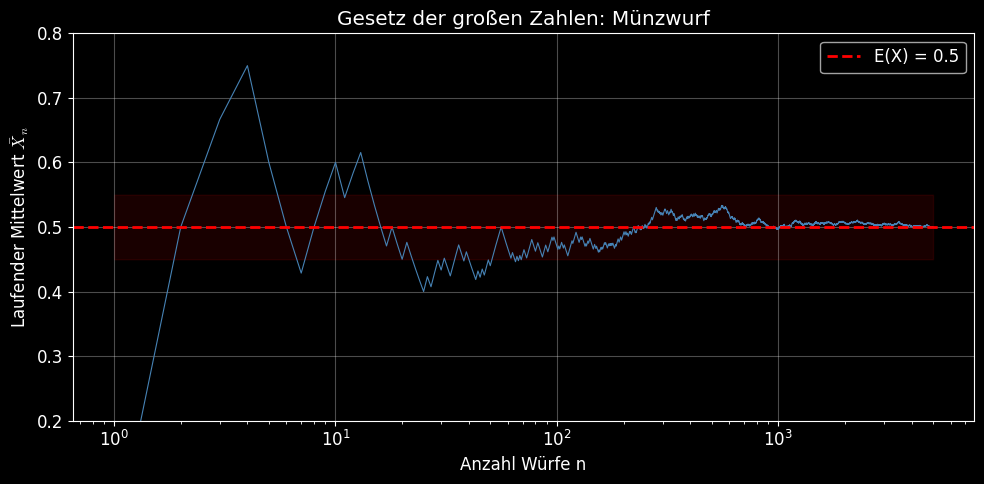

Nach n = 10:    x̄ = 0.6000
Nach n = 100:   x̄ = 0.4700
Nach n = 1000:  x̄ = 0.4970
Nach n = 5000:  x̄ = 0.5000

→ Mit wachsendem n nähert sich x̄ dem Erwartungswert μ = 0.5


In [19]:
np.random.seed(42)
n_max = 5000
wuerfe = np.random.binomial(1, 0.5, n_max)  # 0 = Zahl, 1 = Kopf

# Laufender Mittelwert
laufender_mittelwert = np.cumsum(wuerfe) / np.arange(1, n_max + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, n_max + 1), laufender_mittelwert, color='steelblue', linewidth=0.8)
ax.axhline(0.5, color='red', linestyle='--', linewidth=2, label='E(X) = 0.5')
ax.fill_between(range(1, n_max + 1), 0.45, 0.55, color='red', alpha=0.1)
ax.set_xlabel('Anzahl Würfe n')
ax.set_ylabel(r'Laufender Mittelwert $\bar{X}_n$')
ax.set_title('Gesetz der großen Zahlen: Münzwurf')
ax.set_xscale('log')
ax.legend()
ax.set_ylim(0.2, 0.8)
plt.tight_layout()
plt.show()

print(f"Nach n = 10:    x̄ = {laufender_mittelwert[9]:.4f}")
print(f"Nach n = 100:   x̄ = {laufender_mittelwert[99]:.4f}")
print(f"Nach n = 1000:  x̄ = {laufender_mittelwert[999]:.4f}")
print(f"Nach n = 5000:  x̄ = {laufender_mittelwert[4999]:.4f}")
print(f"\n→ Mit wachsendem n nähert sich x̄ dem Erwartungswert μ = 0.5")


### Demonstration: Würfelwurf

Konvergenz des Mittelwerts gegen $\mu = 3{,}5$ für unterschiedliche Ausgangsverteilungen.


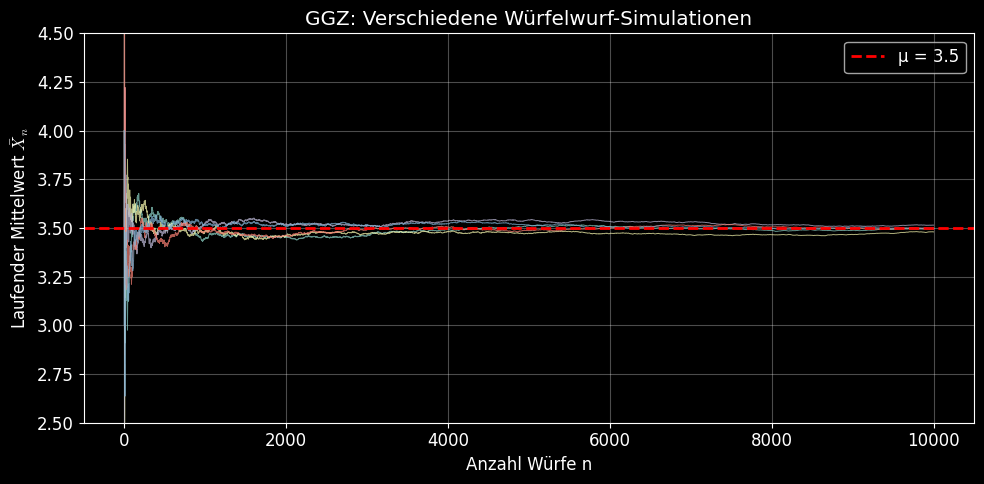

→ Alle 5 Simulationen konvergieren gegen μ = 3.5
→ Die Anfangsschwankungen werden mit wachsendem n immer kleiner


In [20]:
np.random.seed(7)
n_max = 10_000

fig, ax = plt.subplots(figsize=(10, 5))

# 5 unabhängige Simulationen
for i in range(5):
    wuerfe = np.random.randint(1, 7, n_max)
    lauf_mittel = np.cumsum(wuerfe) / np.arange(1, n_max + 1)
    ax.plot(range(1, n_max + 1), lauf_mittel, linewidth=0.7, alpha=0.7)

ax.axhline(3.5, color='red', linestyle='--', linewidth=2, label='μ = 3.5')
ax.set_xlabel('Anzahl Würfe n')
ax.set_ylabel(r'Laufender Mittelwert $\bar{X}_n$')
ax.set_title('GGZ: Verschiedene Würfelwurf-Simulationen')
ax.legend()
ax.set_ylim(2.5, 4.5)
plt.tight_layout()
plt.show()

print("→ Alle 5 Simulationen konvergieren gegen μ = 3.5")
print("→ Die Anfangsschwankungen werden mit wachsendem n immer kleiner")


---
## 9. Zentraler Grenzwertsatz (ZGS)

Für iid Zufallsvariablen mit $E(X_i) = \mu$ und $\mathrm{Var}(X_i) = \sigma^2$ gilt:

$$\bar{X}_n \;\dot{\sim}\; \mathcal{N}\!\left(\mu,\; \frac{\sigma^2}{n}\right) \quad \text{für große } n$$

**Kernaussage:** Das Stichprobenmittel wird approximativ normalverteilt – **egal welche Verteilung die einzelnen $X_i$ haben!**


### Demonstration: Vom Würfel zur Glocke

Wir zeigen, wie die Verteilung von $\bar{X}_n$ für wachsendes $n$ normalverteilt wird, obwohl der einzelne Würfel **diskret gleichverteilt** ist.


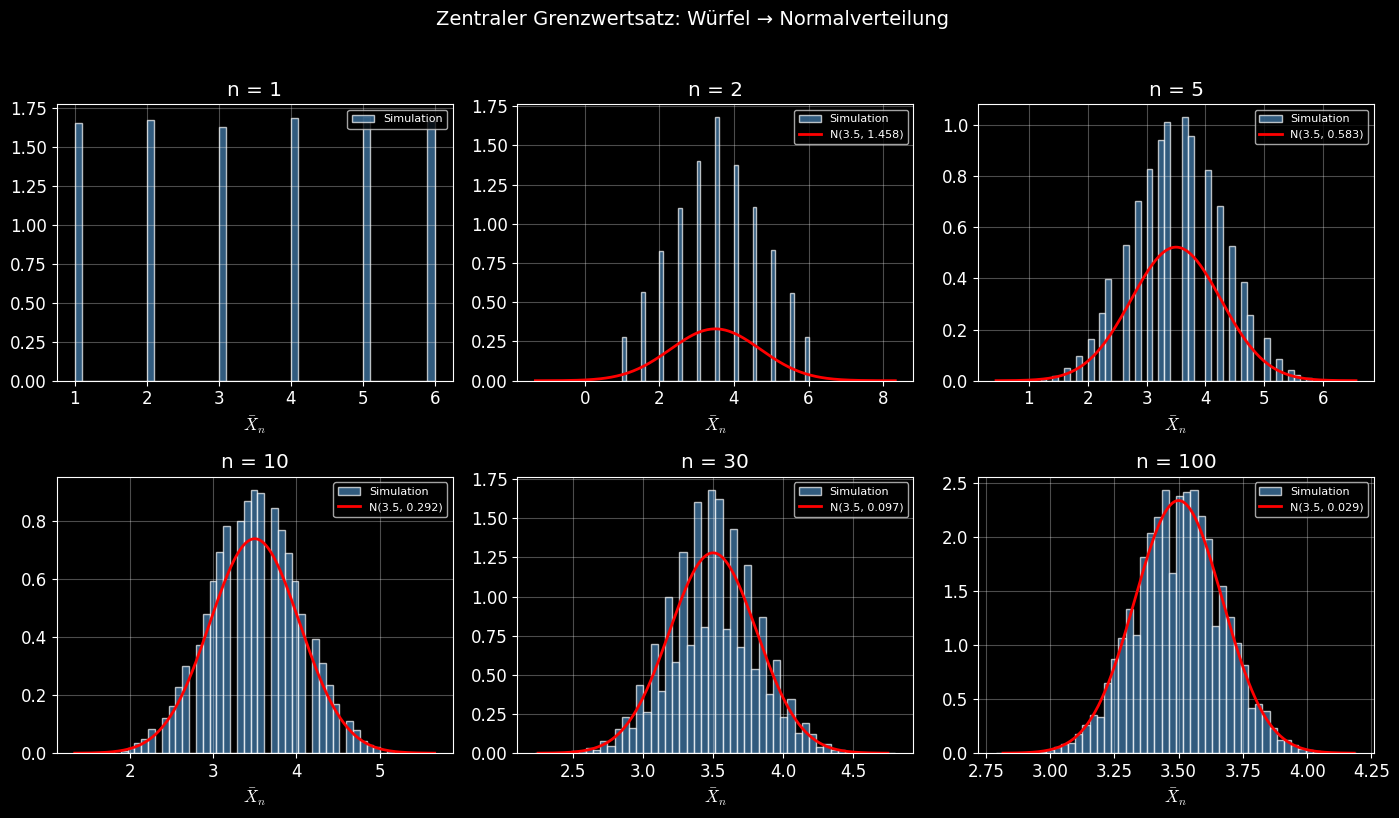

n = 1:   Gleichverteilung (6 Balken)
n = 2:   Dreieckig
n = 5:   Schon fast glockenförmig
n = 30:  Praktisch perfekte Normalverteilung
n = 100: Sehr enge, perfekte Glocke


In [21]:
np.random.seed(42)
n_sim = 50_000

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
sample_sizes = [1, 2, 5, 10, 30, 100]

mu_wuerfel = 3.5
sigma_wuerfel = np.sqrt(35/12)

for ax, n in zip(axes.flatten(), sample_sizes):
    # Simuliere n_sim Stichprobenmittel der Größe n
    mittelwerte = np.array([np.mean(np.random.randint(1, 7, n)) for _ in range(n_sim)])
    
    ax.hist(mittelwerte, bins=50, density=True, color='steelblue', 
            edgecolor='white', alpha=0.7, label='Simulation')
    
    # Theoretische Normalverteilung nach ZGS
    if n > 1:
        x_th = np.linspace(mu_wuerfel - 4*sigma_wuerfel/np.sqrt(n),
                           mu_wuerfel + 4*sigma_wuerfel/np.sqrt(n), 200)
        ax.plot(x_th, stats.norm.pdf(x_th, mu_wuerfel, sigma_wuerfel/np.sqrt(n)),
                'r-', linewidth=2, label=f'N({mu_wuerfel}, {sigma_wuerfel**2/n:.3f})')
    
    ax.set_title(f'n = {n}')
    ax.legend(fontsize=8)
    ax.set_xlabel(r'$\bar{X}_n$')

plt.suptitle('Zentraler Grenzwertsatz: Würfel → Normalverteilung', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("n = 1:   Gleichverteilung (6 Balken)")
print("n = 2:   Dreieckig")
print("n = 5:   Schon fast glockenförmig")
print("n = 30:  Praktisch perfekte Normalverteilung")
print("n = 100: Sehr enge, perfekte Glocke")


### Demonstration: ZGS für verschiedene Ausgangsverteilungen

Der ZGS gilt für **jede** Verteilung mit endlicher Varianz. Hier zeigen wir ihn für drei sehr unterschiedliche Verteilungen.


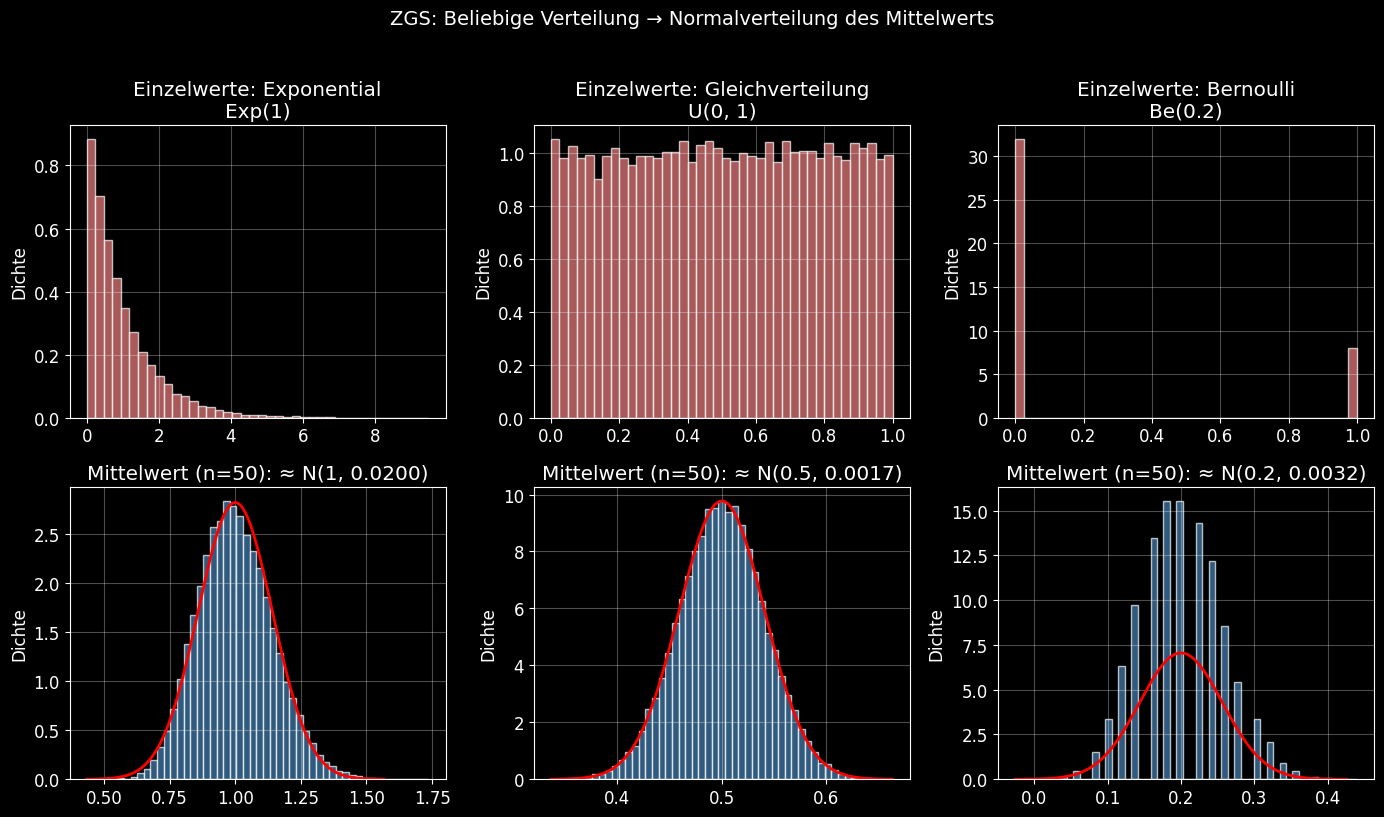

Obere Reihe: Die Ausgangsverteilungen sind sehr unterschiedlich
  - Exponential: stark rechtsschief
  - Gleichverteilung: flach
  - Bernoulli: nur 0 oder 1

Untere Reihe: Alle Stichprobenmittel (n=50) sind normalverteilt!
→ Das ist die Kernaussage des Zentralen Grenzwertsatzes.


In [22]:
np.random.seed(42)
n_sim = 30_000
n = 50  # Stichprobenumfang

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Drei verschiedene Ausgangsverteilungen
vert_namen = ['Exponential\nExp(1)', 'Gleichverteilung\nU(0, 1)', 'Bernoulli\nBe(0.2)']
vert_rvs = [
    lambda size: np.random.exponential(1, size),
    lambda size: np.random.uniform(0, 1, size),
    lambda size: np.random.binomial(1, 0.2, size),
]
vert_params = [
    (1, 1),       # E, Var für Exp(1)
    (0.5, 1/12),  # E, Var für U(0,1)
    (0.2, 0.16),  # E, Var für Be(0.2)
]

for col, (name, rvs_fn, (mu, var)) in enumerate(zip(vert_namen, vert_rvs, vert_params)):
    # Oben: Ausgangsverteilung (n=1)
    ax = axes[0, col]
    einzeln = rvs_fn(n_sim)
    ax.hist(einzeln, bins=40, density=True, color='lightcoral', edgecolor='white', alpha=0.7)
    ax.set_title(f'Einzelwerte: {name}')
    ax.set_ylabel('Dichte')
    
    # Unten: Verteilung des Mittelwerts (n=50)
    ax = axes[1, col]
    mittelwerte = np.array([np.mean(rvs_fn(n)) for _ in range(n_sim)])
    ax.hist(mittelwerte, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.7)
    
    # Theoretische Normalverteilung
    x_th = np.linspace(mu - 4*np.sqrt(var/n), mu + 4*np.sqrt(var/n), 200)
    ax.plot(x_th, stats.norm.pdf(x_th, mu, np.sqrt(var/n)), 'r-', linewidth=2)
    ax.set_title(f'Mittelwert (n={n}): ≈ N({mu}, {var/n:.4f})')
    ax.set_ylabel('Dichte')

plt.suptitle('ZGS: Beliebige Verteilung → Normalverteilung des Mittelwerts', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Obere Reihe: Die Ausgangsverteilungen sind sehr unterschiedlich")
print("  - Exponential: stark rechtsschief")
print("  - Gleichverteilung: flach")
print("  - Bernoulli: nur 0 oder 1")
print()
print("Untere Reihe: Alle Stichprobenmittel (n=50) sind normalverteilt!")
print("→ Das ist die Kernaussage des Zentralen Grenzwertsatzes.")


---
## 10. Unterschied: GGZ vs. ZGS

| | Gesetz der großen Zahlen | Zentraler Grenzwertsatz |
|---|---|---|
| **Aussage** | $\bar{X}_n \to \mu$ (Wert konvergiert) | $\bar{X}_n$ ist normalverteilt |
| **Was konvergiert?** | Der Wert des Mittelwerts | Die gesamte Verteilung |
| **Anwendung** | Schätzung von $\mu$ | Konfidenzintervalle, Tests |


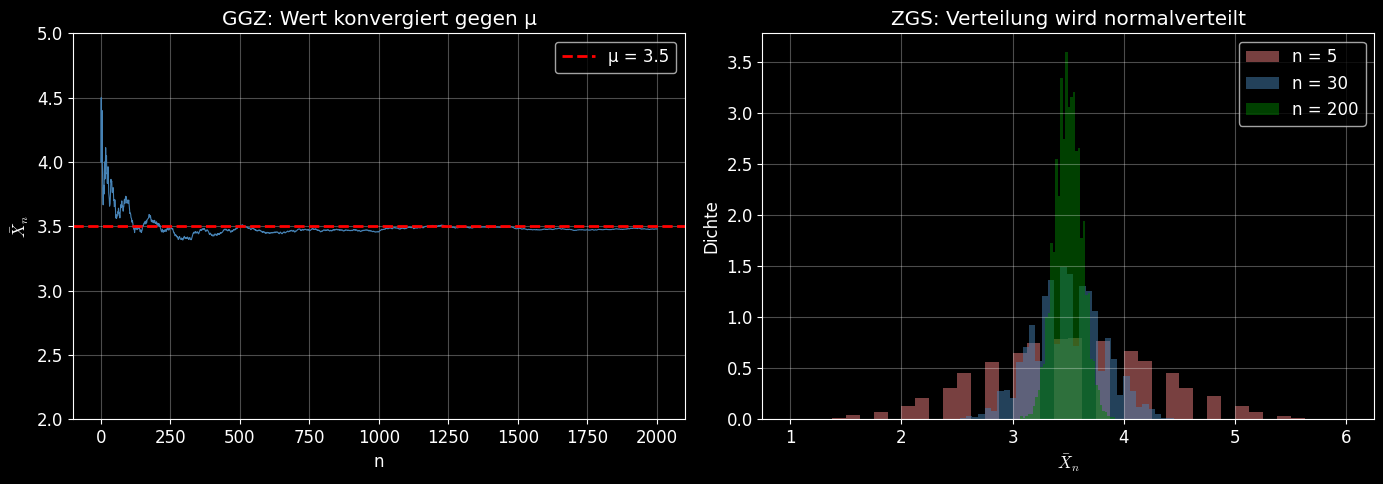

Links (GGZ):  Der Mittelwert KONVERGIERT gegen μ = 3.5
Rechts (ZGS): Die VERTEILUNG des Mittelwerts wird zur Glocke

→ GGZ sagt: 'Der Wert stabilisiert sich.'
→ ZGS sagt: 'Die Verteilung wird normalverteilt.'
→ Beide zusammen bilden die Basis der induktiven Statistik (Kap. 4–7).


In [23]:
# Zusammenfassung in einer Grafik
np.random.seed(42)
n_max = 2000
wuerfe = np.random.randint(1, 7, n_max)
lauf_mittel = np.cumsum(wuerfe) / np.arange(1, n_max + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GGZ: Konvergenz des Werts
ax = axes[0]
ax.plot(range(1, n_max+1), lauf_mittel, 'steelblue', linewidth=0.8)
ax.axhline(3.5, color='red', linestyle='--', linewidth=2, label='μ = 3.5')
ax.set_xlabel('n')
ax.set_ylabel(r'$\bar{X}_n$')
ax.set_title('GGZ: Wert konvergiert gegen μ')
ax.legend()
ax.set_ylim(2, 5)

# ZGS: Verteilung wird normal
ax = axes[1]
n_sizes = [5, 30, 200]
colors = ['lightcoral', 'steelblue', 'green']
for n, col in zip(n_sizes, colors):
    mittelwerte = np.array([np.mean(np.random.randint(1, 7, n)) for _ in range(10000)])
    ax.hist(mittelwerte, bins=40, density=True, alpha=0.5, color=col, label=f'n = {n}')

ax.set_xlabel(r'$\bar{X}_n$')
ax.set_ylabel('Dichte')
ax.set_title('ZGS: Verteilung wird normalverteilt')
ax.legend()

plt.tight_layout()
plt.show()

print("Links (GGZ):  Der Mittelwert KONVERGIERT gegen μ = 3.5")
print("Rechts (ZGS): Die VERTEILUNG des Mittelwerts wird zur Glocke")
print()
print("→ GGZ sagt: 'Der Wert stabilisiert sich.'")
print("→ ZGS sagt: 'Die Verteilung wird normalverteilt.'")
print("→ Beide zusammen bilden die Basis der induktiven Statistik (Kap. 4–7).")


---
## Zusammenfassung

**Lageparameter:** Erwartungswert (Schwerpunkt), Median (robust), Modus (häufigster Wert), Quantile

**Streuungsparameter:** Varianz und Standardabweichung (mittlere quadratische Abweichung), IQR (robust, mittlere 50 %)

**Rechenregeln:**
- $E(aX+b) = aE(X)+b$, $\mathrm{Var}(aX+b) = a^2 \mathrm{Var}(X)$
- Linearität des Erwartungswerts gilt immer, Additivität der Varianz nur bei Unabhängigkeit

**Kovarianz und Korrelation:**
- Cov misst linearen Zusammenhang, $\rho \in [-1, 1]$ ist dimensionslos
- **Korrelation ≠ Kausalität!**

**Mehrdimensionale Zufallsvariablen:**
- Gemeinsame Verteilung → Randverteilungen durch Summation
- Unabhängigkeit: $P(X=x, Y=y) = P(X=x) \cdot P(Y=y)$

**Grenzwertsätze:**
- **GGZ:** $\bar{X}_n \to \mu$ (Stabilisierung)
- **ZGS:** $\bar{X}_n \dot{\sim} N(\mu, \sigma^2/n)$ (Normalverteilung)
- Beide bilden die Grundlage der induktiven Statistik (Kapitel 4–7)
